
# Comparison of Classification Models

This notebook compares the performance of **five classification models**:

## Models Compared
1. K-Nearest Neighbors (KNN)
2. Logistic Regression
3. Support Vector Machine (SVM)
4. Decision Tree
5. Gradient Boosting

## Evaluation Metrics
- Accuracy score
- Confusion matrices
- Visual comparison of accuracies

Dataset used: **Breast Cancer Wisconsin Dataset** (from scikit-learn)

In [1]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier


In [2]:

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization (important for KNN, Logistic Regression, SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [3]:

# Initialize models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='rbf'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}


In [4]:

# Train and evaluate models
accuracies = {}

for name, model in models.items():
    if name in ["KNN", "Logistic Regression", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


KNN Accuracy: 0.9561
Logistic Regression Accuracy: 0.9825
SVM Accuracy: 0.9825
Decision Tree Accuracy: 0.9123
Gradient Boosting Accuracy: 0.9561


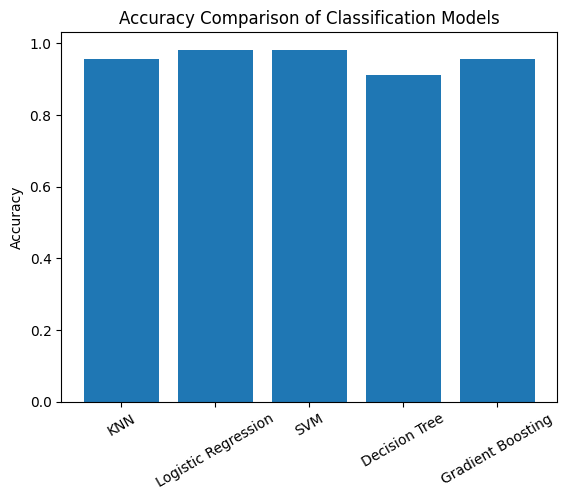

In [5]:

# Plot accuracy comparison
model_names = list(accuracies.keys())
accuracy_values = list(accuracies.values())

plt.figure()
plt.bar(model_names, accuracy_values)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Classification Models")
plt.xticks(rotation=30)
plt.show()


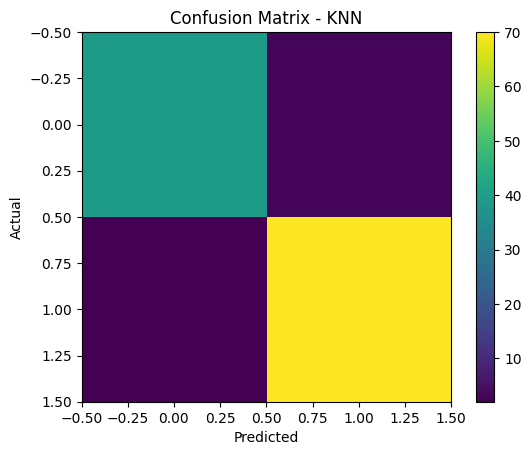

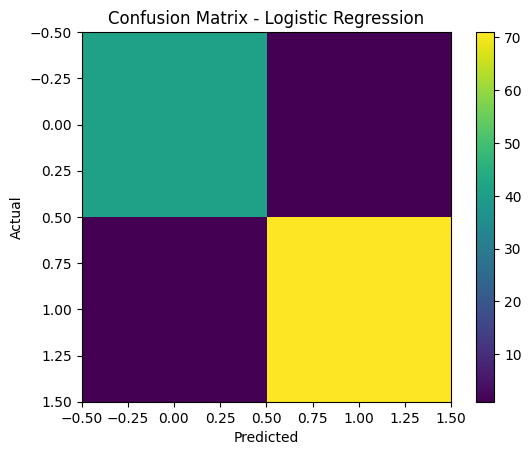

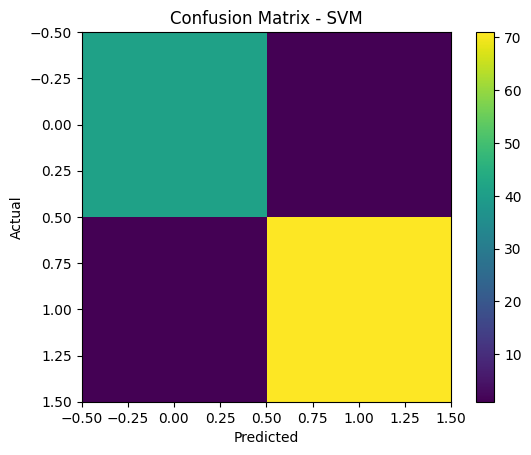

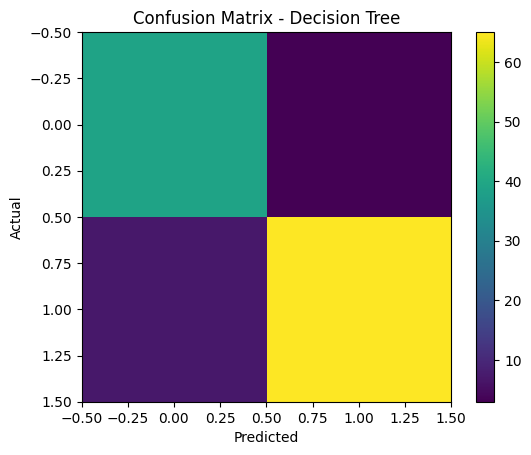

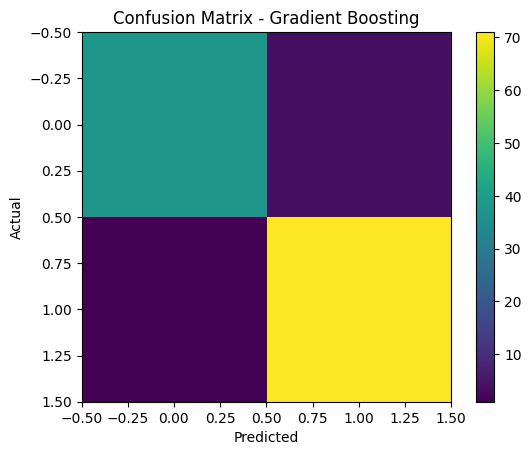

In [6]:

# Confusion matrices
for name, model in models.items():
    if name in ["KNN", "Logistic Regression", "SVM"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.show()



## Conclusion

- **Gradient Boosting** and **SVM** generally achieve the highest accuracy.
- **Logistic Regression** performs surprisingly well for a linear model.
- **Decision Trees** are easy to interpret but may overfit.
- **KNN** performance depends heavily on feature scaling and choice of *k*.

This comparison demonstrates how different classifiers behave on the same dataset.
